In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
url = "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/olivetti.npy"
folder = "data"
filename = os.path.join(folder, "olivetti.npy")


os.makedirs(folder, exist_ok=True)

try:
    from sklearn.datasets import fetch_olivetti_faces
    images = fetch_olivetti_faces().images

except Exception:
    if not os.path.exists(filename):
        !curl -L {url} -o {filename}
    images = np.load(filename)


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [3]:
rng = np.random.default_rng(1)
indices = rng.choice(len(images), size=6, replace=False)

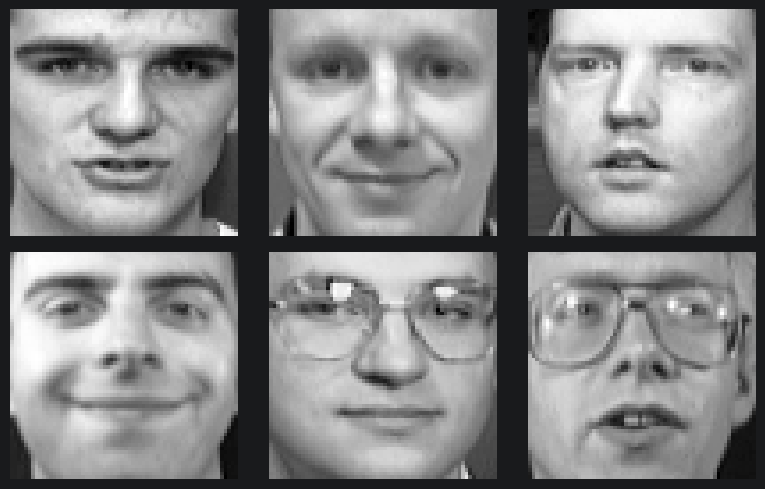

In [4]:
plt.figure(figsize=(8, 5))

for i, idx in enumerate(indices):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[idx], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

Luego de descargar la base de datos y chequearla, se separan las imagenes en grupo de entrenamiento y grupo de testeo. Se utilizaran 8 imagenes por persona para el entrenamiento y dos por persona para el testeo.

In [5]:
n_personas = 40
imgs_por_persona = 10

train_idx = []
test_idx = []

for p in range(n_personas):
    inicio = p * imgs_por_persona
    fin = inicio + imgs_por_persona

    indices_persona = np.arange(inicio, fin)

    test_persona = rng.choice(indices_persona, size=2, replace=False)
    train_persona = np.setdiff1d(indices_persona, test_persona)

    test_idx.extend(test_persona)
    train_idx.extend(train_persona)

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)


images_train = images[train_idx]
images_test = images[test_idx]

print(images_train.shape)
print(images_test.shape)

(320, 64, 64)
(80, 64, 64)


**Linear Discriminant Analysis**

Para el entrenamiento se computan la probabilidad de cada clase, la media de cada clase y una matriz de covarianza "promedio" de todas las clases.


Luego, se puede predecir la probabilidad $\hat{P}(y|x)$ como el $\textit{softmax}$ de la función discriminante:

$$\delta_y = \mu_y^T \Sigma^{-1} x - \frac{1}{2} \mu_y^T \Sigma^{-1} \mu_y + \log{c_y}$$

Donde $c_y$ es la probabilidad estimada de cada clase.

Luego se podrán sintetizar realizaciones, a lo que se le llamará "samping". Esto consiste en simular realizaciones de la normal multivariada correspondiente a las medias de cada clase (La matrz de covarianza es común para todas las clases).

Como la cantidad de muestras de entrenamiento no son suficientes para obtener una matriz de covarianza de rango completo, se regularizara a esta como:

$$\Sigma_{reg} = \Sigma + \lambda I$$

El lambda elegido fue de 1e3, se busca que sea un valor chico para que no apantalle a los valores obtenidos en el entrenamiento, pero lo suficientemente grande para no agregar complejidad computacional.

In [6]:
import numpy as np

class LDA:

    # Inicializar atributos y declarar hiperparámetros
    def __init__(self, lambda_reg=1e-3):
        self.Sigma_inv = None
        self.Sigma = None
        self.mus = None
        self.priors = None
        self.n_classes = None
        self.classes = None
        self.lambda_reg = lambda_reg

    # Etapa de entrenamiento
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.n_classes = len(self.classes)
        n_samples, n_features = X.shape

        self.priors = np.array([np.mean(y == c) for c in self.classes])

        self.mus = np.array([X[y == c].mean(axis=0) for c in self.classes])

        Sigma = np.cov(X, rowvar=False)

        self.Sigma = Sigma + self.lambda_reg * np.eye(n_features)

        self.Sigma_inv = np.linalg.inv(self.Sigma)

        return self

    # Etapa de testeo soft
    def predict_proba(self, X):
        # log-probabilidades (más estable numéricamente)
        log_probs = []

        for idx, c in enumerate(self.classes):
            mu = self.mus[idx]

            diff = X - mu  # (n_samples, n_features)

            quad = np.sum(diff @ self.Sigma_inv * diff, axis=1)

            log_prob = -0.5 * quad + np.log(self.priors[idx])
            log_probs.append(log_prob)

        log_probs = np.vstack(log_probs).T  # (n_samples, n_classes)

        # softmax para obtener probabilidades
        log_probs -= np.max(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= np.sum(probs, axis=1, keepdims=True)

        return probs

    # Etapa de testeo hard
    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

    # Cómputo del Accuracy
    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

    # Simular muestras de forma sintética
    def sampling(self, n_samples=1):
        samples = []
        labels = []

        for _ in range(n_samples):
            # elegir clase según prior
            k = np.random.choice(len(self.classes), p=self.priors)

            mu = self.mus[k]

            # sampleo gaussiano
            x = np.random.multivariate_normal(mu, self.Sigma)

            samples.append(x)
            labels.append(self.classes[k])

        return np.array(samples), np.array(labels)

In [7]:
# === LABELS ===
y = np.repeat(np.arange(40), 10)

# === SPLIT DE LABELS ===
y_train = y[train_idx]
y_test = y[test_idx]

# === FLATTEN (por si vienen como 64x64) ===
X_train = images_train.reshape(len(images_train), -1)
X_test = images_test.reshape(len(images_test), -1)
# === ENTRENAMIENTO ===
lda = LDA(lambda_reg=1e-3)
lda.fit(X_train, y_train)

In [8]:
acc = lda.accuracy(X_test, y_test)
print(acc)

0.95


Al testear se obtuvo una accuracy de .95 por lo que el entrenamiento resultó exitoso.

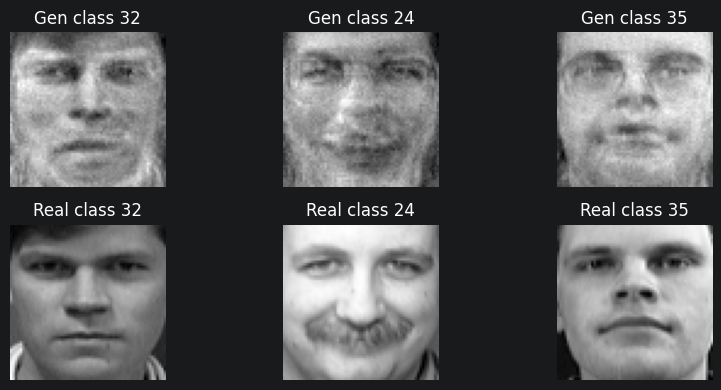

In [9]:
samples, labels = lda.sampling(n_samples=3)

# reshape a imagen
samples = samples.reshape(-1, 64, 64)

plt.figure(figsize=(9,4))

for i in range(3):
    # === imagen generada ===
    plt.subplot(2, 3, i+1)
    plt.imshow(samples[i], cmap='gray')
    plt.title(f"Gen class {labels[i]}")
    plt.axis('off')

    # === imagen real de la misma clase ===
    idx_real = np.random.choice(np.where(y_train == labels[i])[0])
    real_img = X_train[idx_real].reshape(64, 64)

    plt.subplot(2, 3, i+4)
    plt.imshow(real_img, cmap='gray')
    plt.title(f"Real class {labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Se puede ver como las imagenes generadas presentan aspectos claros de caras humanas, que fueron con lo que fue entrenado el algoritmo. Resulta evidente el "Underfitting" generado por tomar una unica matriz de covarianza, ya que aun en personas que no usan anteojos se puede ve runa clara sombra de anteojos. Por ultimo, no resulta facil reconocer que las imagenes generadas son de la persona correspondiente, ya que muchos aspectos caracteristicos se pierden.

**Quadratic discriminant analysis**

Para el discriminante cuadratico los principios son prácticamente los mismos que para el linear, solo que esta vez no se toma una unica matriz de covarianza para todas las clases, si no que se guarda la matriz de cada clase. Esto hace que la complejidad computacional aumente considerablemente, ya que se calculan la inversa y el determinante de las matrices. Esta vez al regularizar se utilizo un valor de lambda distinto para cada clase, en funcion de los autovalores de la matriz obtenida

In [10]:
import numpy as np

class QDA:

    # Inicializar atributos y declarar hiperparámetros
    def __init__(self, alpha=1e-2):
        self.alpha = alpha

        self.classes = None
        self.n_classes = None
        self.priors = None
        self.mus = None
        self.Ls = None          # Cholesky factors
        self.log_dets = None

    # Etapa de entrenamiento
    def fit(self, X, y):
        X = X.astype(np.float32)

        self.classes = np.unique(y)
        self.n_classes = len(self.classes)
        n_samples, n_features = X.shape

        self.priors = np.array([np.mean(y == c) for c in self.classes], dtype=np.float32)

        self.mus = []
        self.Ls = []
        self.log_dets = []

        for c in self.classes:
            Xc = X[y == c]

            mu = Xc.mean(axis=0)

            Sigma = np.cov(Xc, rowvar=False).astype(np.float32)

            # Regularización adaptativa
            eigvals = np.linalg.eigvalsh(Sigma)
            lambda_k = self.alpha * np.max(eigvals)

            Sigma_reg = Sigma + lambda_k * np.eye(n_features, dtype=np.float32)

            # Cholesky
            L = np.linalg.cholesky(Sigma_reg)

            # log(det) usando Cholesky
            log_det = 2 * np.sum(np.log(np.diag(L)))

            self.mus.append(mu)
            self.Ls.append(L)
            self.log_dets.append(log_det)

        self.mus = np.array(self.mus, dtype=np.float32)
        self.log_dets = np.array(self.log_dets, dtype=np.float32)

        return self

    # Etapa de testeo soft
    def predict_proba(self, X):
        X = X.astype(np.float32)

        log_probs = []

        for idx in range(self.n_classes):
            mu = self.mus[idx]
            L = self.Ls[idx]
            log_det = self.log_dets[idx]

            diff = (X - mu).T  # (d, n)

            # resolver L y = diff
            y_sol = np.linalg.solve(L, diff)

            # ||y||^2
            quad = np.sum(y_sol**2, axis=0)

            log_prob = (
                -0.5 * quad
                -0.5 * log_det
                + np.log(self.priors[idx])
            )

            log_probs.append(log_prob)

        log_probs = np.vstack(log_probs).T

        # softmax
        log_probs -= np.max(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= np.sum(probs, axis=1, keepdims=True)

        return probs

    # Etapa de testeo hard
    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

    # Cómputo del Accuracy
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    # Simular muestras de forma sintética (rápido)
    def sampling(self, n_samples=1):
        samples = []
        labels = []

        for _ in range(n_samples):
            k = np.random.choice(self.n_classes, p=self.priors)

            mu = self.mus[k]
            L = self.Ls[k]

            z = np.random.randn(mu.shape[0]).astype(np.float32)
            x = mu + L @ z

            samples.append(x)
            labels.append(self.classes[k])

        return np.array(samples), np.array(labels)

In [11]:
qda = QDA(alpha=1e-5)
qda.fit(X_train, y_train)

In [12]:
acc = lda.accuracy(X_test, y_test)
print(acc)


0.95


Nuevamente el accuracy de testeo es bueno

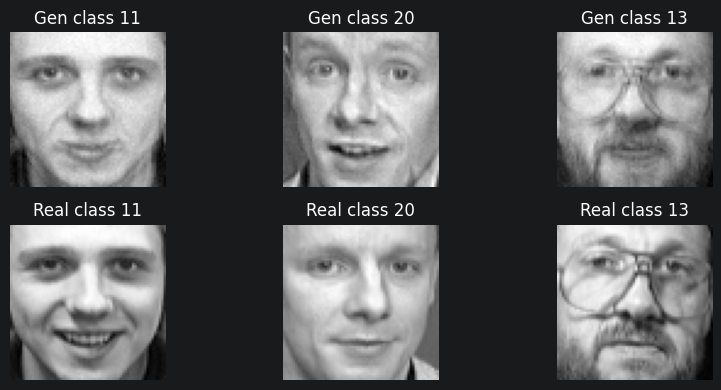

In [13]:
samples, labels = qda.sampling(n_samples=3)

# reshape a imagen
samples = samples.reshape(-1, 64, 64)

plt.figure(figsize=(9,4))

for i in range(3):
    # === generada ===
    plt.subplot(2, 3, i+1)
    plt.imshow(samples[i], cmap='gray')
    plt.title(f"Gen class {labels[i]}")
    plt.axis('off')

    # === real (misma clase) ===
    idx_real = np.random.choice(np.where(y_train == labels[i])[0])
    real_img = X_train[idx_real].reshape(64, 64)

    plt.subplot(2, 3, i+4)
    plt.imshow(real_img, cmap='gray')
    plt.title(f"Real class {labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Con este caso se puede ver mucha mejor calidad en las imagenes, se puede ver como al tener una matriz de covarianza por cada clase, las imagenes tienen los rasgos caracteristicos de cada persona, y no presentan razgos de otras, como si sucedia con el LDA. Se puede reconocer con facilidad que la persona de la imagen generada es la misma que la de la imagen real.

**K nearest neigbors**

Este es un algorimo no paramétrico, ya que no está definido por parámetros. Se basa en analizar los K vecinos mas cercanos al punto de interes, y computar la probabilidad a partir de la probabilidad de cada clase entre los vecinos mas cercanos. La etapa de entrenamiento se basa en recordar todo el set de entrenamiento, y luego en la etapa de prediccion se utilizaran estos para generar la funcion de probabilidad.

In [14]:
class KNN:

    # Inicializar atributos y declarar hiperparámetros
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
        self.classes = None
        self.n_classes = None

    # Etapa de entrenamiento
    def fit(self, X, y):
        self.X_train = X.astype(np.float32)
        self.y_train = y
        self.classes = np.unique(y)
        self.n_classes = len(self.classes)
        return self

    @staticmethod
    def _distances(X, X_train):
        X = X.astype(np.float32)

        X_norm = np.sum(X**2, axis=1, keepdims=True)
        train_norm = np.sum(X_train**2, axis=1)

        dists = X_norm + train_norm - 2 * X @ X_train.T
        return dists

    # Etapa de testeo soft
    def predict_proba(self, X):
        dists = self._distances(X, self.X_train)

        idx = np.argpartition(dists, self.k, axis=1)[:, :self.k]

        probs = np.zeros((X.shape[0], self.n_classes))

        for i in range(X.shape[0]):
            vecinos = self.y_train[idx[i]]

            for j, c in enumerate(self.classes):
                probs[i, j] = np.sum(vecinos == c)

        probs /= self.k
        return probs

    # Etapa de testeo hard
    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

    # Cómputo del Accuracy
    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [ ]:
k_values = np.arange(1, 20)

accuracies = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)

    acc = knn.accuracy(X_test, y_test)
    accuracies.append(acc)11

In [ ]:
plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K (k-NN)")
plt.grid(True)
plt.show()

Se puede ver que como la curva es mayormente decreciente, con su valor maximo en k = 1, esto se puede atribuir a el orden del dataset de entrenamiento, las personas iguales estan agrupadas, por lo que en promedio, los objetos que más informacion aportan al algoritmo son los más cercanos.